# Statistical Significance Testing for Bengali Coreference Resolution

**Master Thesis:** Developing Deep Learning Models for Coreference Resolution in Bengali  
**Author:** Zenith Biswas  
**Saarland University, 2026**

---

## Overview

This notebook performs statistical significance testing across all eight fine-tuning experiments (Experiments 1–8) to determine whether observed performance differences are statistically reliable. The tests operate on **per-document CoNLL F1 scores** computed over the shared 71-document test set.

For aggregate tests across all five models, per-document scores are first **averaged across models** at the document level, yielding 71 independent paired observations. This correctly handles the within-document correlation structure (document difficulty affects all models similarly), avoiding the anti-conservative bias that would result from treating all 355 model×document pairs as independent.

### Tests Performed

1. **Paired Bootstrap Test** (Berg-Kirkpatrick et al., 2012) — the gold standard for comparing NLP systems on shared evaluation data. Resamples documents with replacement (10,000 iterations) and computes the proportion of bootstrap samples where the performance difference changes sign.

2. **Wilcoxon Signed-Rank Test** — a non-parametric paired test that does not assume normality of score differences. Used as secondary confirmation.

3. **Bootstrap 95% Confidence Intervals** — for the mean CoNLL F1 of each experiment–model combination.

4. **Cohen's d Effect Sizes** — to quantify the practical magnitude of differences.

5. **Holm–Bonferroni Correction** — to control the family-wise error rate across 42 simultaneous tests.

### References

- Berg-Kirkpatrick, T., Burkett, D., & Klein, D. (2012). An Empirical Investigation of Statistical Significance in NLP. *Proceedings of EMNLP-CoNLL 2012*, 995–1005.

In [1]:
"""
Cell 1: Imports and Configuration
"""

import json
import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Configuration
N_BOOTSTRAP = 10_000
CONFIDENCE_LEVEL = 0.95
ALPHA = 0.05

print(f"Bootstrap iterations: {N_BOOTSTRAP:,}")
print(f"Confidence level: {CONFIDENCE_LEVEL}")
print(f"Significance level (α): {ALPHA}")
print(f"Random seed: 42")

Bootstrap iterations: 10,000
Confidence level: 0.95
Significance level (α): 0.05
Random seed: 42


In [2]:
"""
Cell 2: Data Paths and Experiment Metadata
"""

# All result JSON files are stored in this directory
DATA_DIR = Path("significance_testing")

EXPERIMENT_FILES = {
    1: "exp_1_fine_tuning_results.json",
    2: "exp_2_fine_tuning_results.json",
    3: "exp_3_fine_tuning_results.json",
    4: "exp_4_fine_tuning_results.json",
    5: "exp_5_fine_tuning_results.json",
    6: "exp_6_bencoref_only_results.json",
    7: "exp_7_bencoref_bt_results.json",
    8: "exp_8_bencoref_para_results.json",
}

EXPERIMENT_NAMES = {
    1: "Mixed Baseline",
    2: "Full + BT",
    3: "Full + Para",
    4: "Hindi Transfer",
    5: "English Transfer",
    6: "BenCoref Only",
    7: "BC + BT",
    8: "BC + Para",
}

# Key comparisons from Table 3.7 of the thesis
# Format: (experiment_a, baseline_b, description, research_questions)
COMPARISONS = [
    (2, 1, "BT augmentation on mixed data",      "RQ3"),
    (3, 1, "Para augmentation on mixed data",     "RQ3"),
    (4, 1, "Hindi cross-lingual transfer",        "RQ4"),
    (5, 1, "English cross-lingual transfer",      "RQ4"),
    (6, 1, "Quality vs quantity (gold vs mixed)", "RQ5"),
    (7, 6, "BT augmentation on gold data",        "RQ3, RQ5"),
    (8, 6, "Para augmentation on gold data",      "RQ3, RQ5"),
]

MODELS = ["MuRIL-Large", "mBERT", "RemBERT", "BanglaBERT-Base", "BERT-Base-Uncased"]

print(f"Data directory: {DATA_DIR}")
print(f"Experiments: {len(EXPERIMENT_FILES)}")
print(f"Comparisons: {len(COMPARISONS)}")
print(f"Models: {len(MODELS)}")
print(f"Total tests: {len(COMPARISONS)} comparisons × {len(MODELS)} models + {len(COMPARISONS)} aggregate = {len(COMPARISONS) * (len(MODELS) + 1)}")

Data directory: significance_testing
Experiments: 8
Comparisons: 7
Models: 5
Total tests: 7 comparisons × 5 models + 7 aggregate = 42


In [3]:
"""
Cell 3: Load Per-Document CoNLL F1 Scores

Each experiment's JSON file contains per-document CoNLL F1 scores for all
71 test documents, computed independently for each model. These scores were
generated during the original experiments by evaluating each document's
predicted clusters against its gold clusters using the CoNLL metric
(average of MUC, B³, and CEAFₑ F1).
"""

def load_all_data():
    """Load per-document CoNLL F1 scores for all experiments and models.
    
    Returns:
        data: dict mapping exp_num -> model_name -> np.array of 71 F1 scores
    """
    data = {}
    
    for exp_num, filename in EXPERIMENT_FILES.items():
        filepath = DATA_DIR / filename
        with open(filepath) as f:
            raw = json.load(f)
        
        data[exp_num] = {}
        for result in raw["results"]:
            model_name = result["model_name"]
            per_doc = result["per_document"]
            scores = np.array([d["CoNLL_F1"] for d in per_doc])
            data[exp_num][model_name] = scores
    
    return data


data = load_all_data()

# Validation
print("Data Validation")
print("=" * 70)
for exp_num in sorted(data.keys()):
    models = list(data[exp_num].keys())
    n_docs = [len(data[exp_num][m]) for m in models]
    status = "✓" if all(n == 71 for n in n_docs) else "✗"
    print(f"  {status} Exp {exp_num} ({EXPERIMENT_NAMES[exp_num]:<20}): "
          f"{len(models)} models, {n_docs[0]} docs each")

# Verify document alignment across experiments
with open(DATA_DIR / EXPERIMENT_FILES[1]) as f:
    ref_ids = [d['doc_id'] for d in json.load(f)['results'][0]['per_document']]

aligned = True
for exp_num, filename in EXPERIMENT_FILES.items():
    with open(DATA_DIR / filename) as f:
        ids = [d['doc_id'] for d in json.load(f)['results'][0]['per_document']]
    if ids != ref_ids:
        aligned = False
        print(f"  ✗ WARNING: Exp {exp_num} doc_ids do not match Exp 1!")

print(f"\n  Document alignment across all experiments: {'✓ Verified' if aligned else '✗ MISMATCH'}")
print(f"  Test documents: {len(ref_ids)}")

Data Validation
  ✓ Exp 1 (Mixed Baseline      ): 5 models, 71 docs each
  ✓ Exp 2 (Full + BT           ): 5 models, 71 docs each
  ✓ Exp 3 (Full + Para         ): 5 models, 71 docs each
  ✓ Exp 4 (Hindi Transfer      ): 5 models, 71 docs each
  ✓ Exp 5 (English Transfer    ): 5 models, 71 docs each
  ✓ Exp 6 (BenCoref Only       ): 5 models, 71 docs each
  ✓ Exp 7 (BC + BT             ): 5 models, 71 docs each
  ✓ Exp 8 (BC + Para           ): 5 models, 71 docs each

  Document alignment across all experiments: ✓ Verified
  Test documents: 71


---

## Statistical Test Definitions

The following cell defines the core statistical functions used throughout this analysis.

In [4]:
"""
Cell 4: Statistical Test Functions
"""

def paired_bootstrap_test(scores_a, scores_b, n_bootstrap=N_BOOTSTRAP):
    """
    Paired bootstrap significance test (Berg-Kirkpatrick et al., 2012).
    
    Procedure:
      1. Compute the observed difference δ = mean(A) - mean(B)
      2. For each of n_bootstrap iterations:
         a. Sample n documents WITH replacement (same indices for both systems)
         b. Compute δ* = mean(A*) - mean(B*)
      3. p-value = 2 × min(proportion of δ* ≤ 0, proportion of δ* > 0)
    
    This is a two-sided test: it tests whether the systems differ,
    regardless of direction.
    
    Args:
        scores_a: np.array of per-document scores for system A
        scores_b: np.array of per-document scores for system B
        n_bootstrap: number of bootstrap iterations
    
    Returns:
        p_value: two-sided p-value
        observed_diff: mean(A) - mean(B)
        ci_lower: 2.5th percentile of bootstrap differences
        ci_upper: 97.5th percentile of bootstrap differences
    """
    n_docs = len(scores_a)
    assert len(scores_a) == len(scores_b) == n_docs
    
    observed_diff = np.mean(scores_a) - np.mean(scores_b)
    
    # Bootstrap resampling
    bootstrap_diffs = np.zeros(n_bootstrap)
    for i in range(n_bootstrap):
        indices = np.random.randint(0, n_docs, size=n_docs)
        boot_a = scores_a[indices]
        boot_b = scores_b[indices]
        bootstrap_diffs[i] = np.mean(boot_a) - np.mean(boot_b)
    
    # Two-sided p-value
    if observed_diff >= 0:
        p_value = np.mean(bootstrap_diffs <= 0)
    else:
        p_value = np.mean(bootstrap_diffs >= 0)
    p_value = 2 * min(p_value, 1 - p_value)
    p_value = min(p_value, 1.0)
    
    # 95% confidence interval of the difference
    ci_lower = np.percentile(bootstrap_diffs, 2.5)
    ci_upper = np.percentile(bootstrap_diffs, 97.5)
    
    return p_value, observed_diff, ci_lower, ci_upper


def wilcoxon_test(scores_a, scores_b):
    """
    Wilcoxon signed-rank test (non-parametric paired test).
    
    Tests whether the distribution of paired differences is symmetric
    around zero. Unlike the t-test, this does not assume normality.
    
    Returns:
        p_value: two-sided p-value
        statistic: test statistic
    """
    diffs = scores_a - scores_b
    nonzero = diffs[diffs != 0]
    
    if len(nonzero) < 10:
        return 1.0, 0.0  # Too few non-tied pairs
    
    try:
        stat, p_value = stats.wilcoxon(scores_a, scores_b, alternative='two-sided')
        return p_value, stat
    except ValueError:
        return 1.0, 0.0


def bootstrap_confidence_interval(scores, n_bootstrap=N_BOOTSTRAP, ci=95):
    """
    Compute bootstrap confidence interval for the mean.
    
    Resamples the scores with replacement and computes the mean for
    each bootstrap sample to estimate the sampling distribution.
    """
    n = len(scores)
    boot_means = np.zeros(n_bootstrap)
    for i in range(n_bootstrap):
        indices = np.random.randint(0, n, size=n)
        boot_means[i] = np.mean(scores[indices])
    
    alpha = (100 - ci) / 2
    return np.percentile(boot_means, alpha), np.percentile(boot_means, 100 - alpha)


def cohens_d_paired(scores_a, scores_b):
    """
    Cohen's d for paired samples.
    
    d = mean(differences) / std(differences)
    
    Interpretation:
        |d| < 0.2  : negligible
        0.2 ≤ |d| < 0.5 : small
        0.5 ≤ |d| < 0.8 : medium
        |d| ≥ 0.8  : large
    """
    diffs = scores_a - scores_b
    sd = np.std(diffs, ddof=1)
    if sd == 0:
        return 0.0
    return np.mean(diffs) / sd


def holm_bonferroni_correction(p_values):
    """
    Holm–Bonferroni method for multiple comparison correction.
    
    Less conservative than Bonferroni while still controlling the
    family-wise error rate (FWER). Procedure:
      1. Sort p-values in ascending order
      2. Multiply the k-th smallest p-value by (m - k + 1)
      3. Enforce monotonicity
    
    Returns:
        corrected: list of corrected p-values in original order
    """
    n = len(p_values)
    indexed = sorted(enumerate(p_values), key=lambda x: x[1])
    
    corrected = [0.0] * n
    max_so_far = 0.0
    for rank, (orig_idx, p) in enumerate(indexed):
        adjusted = p * (n - rank)
        adjusted = min(adjusted, 1.0)
        adjusted = max(adjusted, max_so_far)  # Enforce monotonicity
        corrected[orig_idx] = adjusted
        max_so_far = adjusted
    
    return corrected


def significance_stars(p):
    """Return significance markers."""
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "n.s."


def effect_size_label(d):
    """Return effect size interpretation."""
    d = abs(d)
    if d < 0.2: return "negligible"
    elif d < 0.5: return "small"
    elif d < 0.8: return "medium"
    else: return "large"


print("✓ All statistical test functions defined")

✓ All statistical test functions defined


---

## Part 1: Per-Model Paired Bootstrap Tests

For each of the 7 key comparisons from Table 3.7, we test whether the experimental condition differs significantly from its baseline, separately for each of the 5 models and aggregated across all models.

Each test pairs per-document CoNLL F1 scores across the same 71 test documents, ensuring matched observations.

For **aggregate tests**, we first average each document's CoNLL F1 across all 5 models, yielding 71 independent paired observations. This correctly accounts for within-document correlation across models (scores from different models on the same document are correlated because document difficulty affects all models). The alternative approach of pooling all 355 model×document pairs and resampling independently would violate the bootstrap's independence assumption and produce anti-conservative p-values.

In [5]:
"""
Cell 5: Run All Paired Significance Tests
"""

all_results = []
raw_p_values = []

print("=" * 95)
print("PAIRED BOOTSTRAP SIGNIFICANCE TESTS")
print("=" * 95)

for exp_a, exp_b, description, rq in COMPARISONS:
    print(f"\n{'─' * 95}")
    print(f"Exp {exp_a} ({EXPERIMENT_NAMES[exp_a]}) vs "
          f"Exp {exp_b} ({EXPERIMENT_NAMES[exp_b]})")
    print(f"Question: {description} | Research Question(s): {rq}")
    print(f"{'─' * 95}")
    print(f"{'Model':<22} {'Mean A':>8} {'Mean B':>8} {'Δ F1':>10} "
          f"{'95% CI':>22} {'Boot p':>10} {'Wilcox p':>10}")
    print(f"{'─' * 95}")
    
    # Per-model tests
    for model in MODELS:
        scores_a = data[exp_a][model]
        scores_b = data[exp_b][model]
        
        boot_p, obs_diff, ci_lo, ci_hi = paired_bootstrap_test(scores_a, scores_b)
        wilc_p, _ = wilcoxon_test(scores_a, scores_b)
        d = cohens_d_paired(scores_a, scores_b)
        
        all_results.append({
            "exp_a": exp_a, "exp_b": exp_b,
            "exp_a_name": EXPERIMENT_NAMES[exp_a],
            "exp_b_name": EXPERIMENT_NAMES[exp_b],
            "description": description, "rq": rq,
            "model": model,
            "mean_a": np.mean(scores_a),
            "mean_b": np.mean(scores_b),
            "diff": obs_diff,
            "ci_lower": ci_lo, "ci_upper": ci_hi,
            "bootstrap_p": boot_p,
            "wilcoxon_p": wilc_p,
            "cohens_d": d,
            "effect_size": effect_size_label(d),
        })
        raw_p_values.append(boot_p)
        
        print(f"{model:<22} {np.mean(scores_a):>7.2f} {np.mean(scores_b):>7.2f} "
              f"{obs_diff:>+8.2f}pp "
              f"[{ci_lo:>+7.2f}, {ci_hi:>+7.2f}] "
              f"{boot_p:>10.4f} {wilc_p:>10.4f}")
    
    # Aggregate test (document-level averaging)
    # Average each document's score across all 5 models first,
    # yielding 71 independent paired observations. This correctly
    # accounts for within-document correlation across models.
    avg_a = np.mean([data[exp_a][m] for m in MODELS], axis=0)  # shape (71,)
    avg_b = np.mean([data[exp_b][m] for m in MODELS], axis=0)  # shape (71,)
    boot_p_agg, diff_agg, ci_lo_agg, ci_hi_agg = paired_bootstrap_test(avg_a, avg_b)
    wilc_p_agg, _ = wilcoxon_test(avg_a, avg_b)
    d_agg = cohens_d_paired(avg_a, avg_b)
    
    all_results.append({
        "exp_a": exp_a, "exp_b": exp_b,
        "exp_a_name": EXPERIMENT_NAMES[exp_a],
        "exp_b_name": EXPERIMENT_NAMES[exp_b],
        "description": description, "rq": rq,
        "model": "AGGREGATE",
        "mean_a": np.mean(avg_a), "mean_b": np.mean(avg_b),
        "diff": diff_agg,
        "ci_lower": ci_lo_agg, "ci_upper": ci_hi_agg,
        "bootstrap_p": boot_p_agg,
        "wilcoxon_p": wilc_p_agg,
        "cohens_d": d_agg,
        "effect_size": effect_size_label(d_agg),
    })
    raw_p_values.append(boot_p_agg)
    
    print(f"{'─' * 95}")
    print(f"{'AGGREGATE':<22} {np.mean(avg_a):>7.2f} {np.mean(avg_b):>7.2f} "
          f"{diff_agg:>+8.2f}pp "
          f"[{ci_lo_agg:>+7.2f}, {ci_hi_agg:>+7.2f}] "
          f"{boot_p_agg:>10.4f} {wilc_p_agg:>10.4f}")

print(f"\n\n✓ Completed {len(all_results)} tests "
      f"({len(COMPARISONS)} comparisons × {len(MODELS)} models + {len(COMPARISONS)} aggregate)")

PAIRED BOOTSTRAP SIGNIFICANCE TESTS

───────────────────────────────────────────────────────────────────────────────────────────────
Exp 2 (Full + BT) vs Exp 1 (Mixed Baseline)
Question: BT augmentation on mixed data | Research Question(s): RQ3
───────────────────────────────────────────────────────────────────────────────────────────────
Model                    Mean A   Mean B       Δ F1                 95% CI     Boot p   Wilcox p
───────────────────────────────────────────────────────────────────────────────────────────────
MuRIL-Large              41.16   42.55    -1.40pp [  -3.46,   +0.43]     0.1498     0.8424
mBERT                    39.21   37.62    +1.59pp [  +0.05,   +3.31]     0.0414     0.6748
RemBERT                  41.08   39.39    +1.69pp [  +0.23,   +3.24]     0.0204     0.1444
BanglaBERT-Base          40.87   39.92    +0.95pp [  -0.71,   +2.67]     0.2678     0.7276
BERT-Base-Uncased        40.66   38.22    +2.44pp [  -0.10,   +5.27]     0.0594     0.5349
───────────

---

## Part 2: Multiple Comparison Correction

With 42 simultaneous tests, the probability of at least one false positive is substantially inflated. The Holm–Bonferroni method controls the family-wise error rate while being less conservative than standard Bonferroni correction.

In [6]:
"""
Cell 6: Apply Holm-Bonferroni Correction (Per-Family)

Two correction families:
  1. Aggregate tests: 7 comparisons → correct across 7 tests
  2. Per-model tests: 5 models per comparison → correct within each comparison

This avoids penalizing per-model tests for the existence of unrelated
comparisons, while still controlling the family-wise error rate within
each meaningful test family.
"""

# --- Family 1: Aggregate tests (7 tests) ---
agg_indices = [i for i, r in enumerate(all_results) if r["model"] == "AGGREGATE"]
agg_p_raw = [all_results[i]["bootstrap_p"] for i in agg_indices]
agg_p_corrected = holm_bonferroni_correction(agg_p_raw)

for idx, agg_i in enumerate(agg_indices):
    all_results[agg_i]["corrected_p"] = agg_p_corrected[idx]
    all_results[agg_i]["sig_raw"] = significance_stars(all_results[agg_i]["bootstrap_p"])
    all_results[agg_i]["sig_corrected"] = significance_stars(agg_p_corrected[idx])

# --- Family 2: Per-model tests (5 tests per comparison) ---
for exp_a, exp_b, description, rq in COMPARISONS:
    model_indices = [
        i for i, r in enumerate(all_results)
        if r["exp_a"] == exp_a and r["exp_b"] == exp_b and r["model"] != "AGGREGATE"
    ]
    model_p_raw = [all_results[i]["bootstrap_p"] for i in model_indices]
    model_p_corrected = holm_bonferroni_correction(model_p_raw)

    for idx, m_i in enumerate(model_indices):
        all_results[m_i]["corrected_p"] = model_p_corrected[idx]
        all_results[m_i]["sig_raw"] = significance_stars(all_results[m_i]["bootstrap_p"])
        all_results[m_i]["sig_corrected"] = significance_stars(model_p_corrected[idx])

df = pd.DataFrame(all_results)

# --- Summary ---
all_corrected_p = [r["corrected_p"] for r in all_results]

print("Holm–Bonferroni Correction Summary (Per-Family)")
print("=" * 75)
print(f"Correction families:")
print(f"  Aggregate: {len(agg_indices)} tests (7 comparisons)")
print(f"  Per-model: {len(COMPARISONS)} families × {len(MODELS)} tests each")
print()
print(f"Total tests: {len(all_results)}")
print(f"Significant before correction (p < 0.05): "
      f"{sum(1 for r in all_results if r['bootstrap_p'] < 0.05)}")
print(f"Significant after correction (p < 0.05):  "
      f"{sum(1 for p in all_corrected_p if p < 0.05)}")

# Show significant aggregate tests
print(f"\nAggregate tests significant after correction:")
agg_df = df[df["model"] == "AGGREGATE"]
agg_sig = agg_df[agg_df["corrected_p"] < 0.05].sort_values("corrected_p")
if len(agg_sig) > 0:
    for _, row in agg_sig.iterrows():
        print(f"  Exp {row['exp_a']} vs {row['exp_b']} "
              f"({row['description'][:40]:<40}) "
              f"Δ={row['diff']:>+6.2f}pp  "
              f"p_raw={row['bootstrap_p']:.4f}  "
              f"p_corr={row['corrected_p']:.4f} {row['sig_corrected']}")
else:
    print("  None")

# Show significant per-model tests
print(f"\nPer-model tests significant after correction:")
model_df = df[df["model"] != "AGGREGATE"]
model_sig = model_df[model_df["corrected_p"] < 0.05].sort_values("corrected_p")
if len(model_sig) > 0:
    for _, row in model_sig.iterrows():
        print(f"  {row['model']:<22} Exp {row['exp_a']} vs {row['exp_b']} "
              f"({row['description'][:35]:<35}) "
              f"Δ={row['diff']:>+6.2f}pp  "
              f"p_raw={row['bootstrap_p']:.4f}  "
              f"p_corr={row['corrected_p']:.4f} {row['sig_corrected']}")
else:
    print("  None")


Holm–Bonferroni Correction Summary (Per-Family)
Correction families:
  Aggregate: 7 tests (7 comparisons)
  Per-model: 7 families × 5 tests each

Total tests: 42
Significant before correction (p < 0.05): 19
Significant after correction (p < 0.05):  9

Aggregate tests significant after correction:
  Exp 6 vs 1 (Quality vs quantity (gold vs mixed)     ) Δ= +2.63pp  p_raw=0.0010  p_corr=0.0070 **
  Exp 7 vs 6 (BT augmentation on gold data            ) Δ= -0.81pp  p_raw=0.0026  p_corr=0.0156 *

Per-model tests significant after correction:
  mBERT                  Exp 6 vs 1 (Quality vs quantity (gold vs mixed)) Δ= +4.46pp  p_raw=0.0000  p_corr=0.0000 ***
  mBERT                  Exp 3 vs 1 (Para augmentation on mixed data    ) Δ= +2.78pp  p_raw=0.0004  p_corr=0.0020 **
  mBERT                  Exp 4 vs 1 (Hindi cross-lingual transfer       ) Δ= +3.28pp  p_raw=0.0010  p_corr=0.0050 **
  MuRIL-Large            Exp 7 vs 6 (BT augmentation on gold data       ) Δ= -2.73pp  p_raw=0.0012  p_corr

---

## Part 3: Publication-Ready Summary Tables

In [7]:
"""
Cell 7: Aggregate Significance Summary Table

This table summarises the key finding for each comparison across all models.
This is the most important table for the thesis.
"""

agg_df = df[df["model"] == "AGGREGATE"].copy()

print("=" * 95)
print("AGGREGATE SIGNIFICANCE SUMMARY")
print("Paired bootstrap test, 10,000 iterations, Holm–Bonferroni corrected (per-family)")
print("=" * 95)
print(f"{'Comparison':<45} {'Δ F1':>9} {'95% CI':>20} {'p (corr)':>10} {'Sig':>5}")
print(f"{'─' * 95}")

for _, row in agg_df.iterrows():
    label = f"Exp {row['exp_a']} vs {row['exp_b']}: {row['description'][:32]}"
    ci_str = f"[{row['ci_lower']:>+6.2f}, {row['ci_upper']:>+6.2f}]"
    p_str = f"{row['corrected_p']:.4f}" if row['corrected_p'] > 0.0005 else "< 0.001"
    print(f"{label:<45} {row['diff']:>+7.2f}pp {ci_str:>20} {p_str:>10} {row['sig_corrected']:>5}")

print(f"{'─' * 95}")
print("* p < 0.05, ** p < 0.01, *** p < 0.001")

AGGREGATE SIGNIFICANCE SUMMARY
Paired bootstrap test, 10,000 iterations, Holm–Bonferroni corrected (per-family)
Comparison                                         Δ F1               95% CI   p (corr)   Sig
───────────────────────────────────────────────────────────────────────────────────────────────
Exp 2 vs 1: BT augmentation on mixed data       +1.05pp     [ +0.09,  +2.06]     0.1470  n.s.
Exp 3 vs 1: Para augmentation on mixed data     +0.83pp     [ +0.05,  +1.65]     0.1512  n.s.
Exp 4 vs 1: Hindi cross-lingual transfer        +0.99pp     [ -0.24,  +2.28]     0.2328  n.s.
Exp 5 vs 1: English cross-lingual transfer      +0.92pp     [ -0.83,  +2.85]     0.3260  n.s.
Exp 6 vs 1: Quality vs quantity (gold vs mix    +2.63pp     [ +0.94,  +4.54]     0.0070    **
Exp 7 vs 6: BT augmentation on gold data        -0.81pp     [ -1.41,  -0.25]     0.0156     *
Exp 8 vs 6: Para augmentation on gold data      -0.46pp     [ -0.97,  +0.04]     0.2076  n.s.
────────────────────────────────────────

In [8]:
"""
Cell 8: Per-Model Significance Table

Detailed breakdown showing which individual models show significant effects.
"""

model_df = df[df["model"] != "AGGREGATE"].copy()

print("=" * 105)
print("PER-MODEL SIGNIFICANCE (Holm–Bonferroni corrected)")
print("=" * 105)

for exp_a, exp_b, description, rq in COMPARISONS:
    subset = model_df[(model_df["exp_a"] == exp_a) & (model_df["exp_b"] == exp_b)]
    n_sig = len(subset[subset["corrected_p"] < 0.05])
    
    print(f"\n  Exp {exp_a} vs Exp {exp_b}: {description} ({rq}) — {n_sig}/5 significant")
    print(f"  {'Model':<22} {'Exp '+str(exp_a):>7} {'Exp '+str(exp_b):>7} "
          f"{'Δ F1':>8} {'d':>7} {'p_raw':>8} {'p_corr':>8} {'Sig':>5}")
    print(f"  {'─' * 82}")
    
    for _, row in subset.iterrows():
        print(f"  {row['model']:<22} {row['mean_a']:>6.2f} {row['mean_b']:>6.2f} "
              f"{row['diff']:>+6.2f}pp {row['cohens_d']:>+6.3f} "
              f"{row['bootstrap_p']:>8.4f} {row['corrected_p']:>8.4f} "
              f"{row['sig_corrected']:>5}")

PER-MODEL SIGNIFICANCE (Holm–Bonferroni corrected)

  Exp 2 vs Exp 1: BT augmentation on mixed data (RQ3) — 0/5 significant
  Model                    Exp 2   Exp 1     Δ F1       d    p_raw   p_corr   Sig
  ──────────────────────────────────────────────────────────────────────────────────
  MuRIL-Large             41.16  42.55  -1.40pp -0.164   0.1498   0.2996  n.s.
  mBERT                   39.21  37.62  +1.59pp +0.225   0.0414   0.1656  n.s.
  RemBERT                 41.08  39.39  +1.69pp +0.261   0.0204   0.1020  n.s.
  BanglaBERT-Base         40.87  39.92  +0.95pp +0.132   0.2678   0.2996  n.s.
  BERT-Base-Uncased       40.66  38.22  +2.44pp +0.210   0.0594   0.1782  n.s.

  Exp 3 vs Exp 1: Para augmentation on mixed data (RQ3) — 2/5 significant
  Model                    Exp 3   Exp 1     Δ F1       d    p_raw   p_corr   Sig
  ──────────────────────────────────────────────────────────────────────────────────
  MuRIL-Large             40.99  42.55  -1.56pp -0.226   0.0410   0.1230

---

## Part 4: Bootstrap Confidence Intervals

In [9]:
"""
Cell 9: Bootstrap 95% Confidence Intervals per Experiment × Model
"""

ci_results = []

print("=" * 75)
print("BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 75)

for exp_num in sorted(EXPERIMENT_FILES.keys()):
    print(f"\n  Experiment {exp_num} ({EXPERIMENT_NAMES[exp_num]})")
    print(f"  {'Model':<22} {'Mean':>8} {'95% CI':>22} {'Std':>8}")
    print(f"  {'─' * 62}")
    
    for model in MODELS:
        scores = data[exp_num][model]
        ci_lo, ci_hi = bootstrap_confidence_interval(scores)
        mean_f1 = np.mean(scores)
        std_f1 = np.std(scores)
        
        print(f"  {model:<22} {mean_f1:>7.2f}  [{ci_lo:>6.2f}, {ci_hi:>6.2f}]  {std_f1:>7.2f}")
        
        ci_results.append({
            "experiment": exp_num,
            "exp_name": EXPERIMENT_NAMES[exp_num],
            "model": model,
            "mean_f1": mean_f1,
            "ci_lower": ci_lo,
            "ci_upper": ci_hi,
            "std": std_f1,
        })

ci_df = pd.DataFrame(ci_results)
print(f"\n✓ Computed {len(ci_results)} confidence intervals")

BOOTSTRAP 95% CONFIDENCE INTERVALS

  Experiment 1 (Mixed Baseline)
  Model                      Mean                 95% CI      Std
  ──────────────────────────────────────────────────────────────
  MuRIL-Large              42.55  [ 39.56,  45.55]    12.81
  mBERT                    37.62  [ 34.83,  40.56]    12.33
  RemBERT                  39.39  [ 36.68,  42.25]    12.06
  BanglaBERT-Base          39.92  [ 37.38,  42.50]    11.03
  BERT-Base-Uncased        38.22  [ 35.75,  40.80]    10.84

  Experiment 2 (Full + BT)
  Model                      Mean                 95% CI      Std
  ──────────────────────────────────────────────────────────────
  MuRIL-Large              41.16  [ 38.52,  43.94]    11.74
  mBERT                    39.21  [ 36.44,  42.09]    12.24
  RemBERT                  41.08  [ 38.41,  43.94]    11.96
  BanglaBERT-Base          40.87  [ 37.93,  43.91]    12.64
  BERT-Base-Uncased        40.66  [ 37.52,  43.79]    13.54

  Experiment 3 (Full + Para)
  Model     

---

## Part 5: Effect Size Analysis (Cohen's d)

In [10]:
"""
Cell 10: Effect Size Summary

Cohen's d for paired samples quantifies the practical magnitude of
differences, independent of sample size.

Interpretation (Cohen, 1988):
    |d| < 0.2  : negligible
    0.2 ≤ |d| < 0.5 : small
    0.5 ≤ |d| < 0.8 : medium
    |d| ≥ 0.8  : large
"""

print("=" * 75)
print("EFFECT SIZE ANALYSIS (Cohen's d, paired)")
print("=" * 75)

for exp_a, exp_b, description, rq in COMPARISONS:
    print(f"\n  Exp {exp_a} vs {exp_b}: {description}")
    print(f"  {'Model':<22} {'d':>8} {'Interpretation':>15}")
    print(f"  {'─' * 48}")
    
    for model in MODELS:
        d = cohens_d_paired(data[exp_a][model], data[exp_b][model])
        print(f"  {model:<22} {d:>+7.3f}  {effect_size_label(d):>14}")

EFFECT SIZE ANALYSIS (Cohen's d, paired)

  Exp 2 vs 1: BT augmentation on mixed data
  Model                         d  Interpretation
  ────────────────────────────────────────────────
  MuRIL-Large             -0.164      negligible
  mBERT                   +0.225           small
  RemBERT                 +0.261           small
  BanglaBERT-Base         +0.132      negligible
  BERT-Base-Uncased       +0.210           small

  Exp 3 vs 1: Para augmentation on mixed data
  Model                         d  Interpretation
  ────────────────────────────────────────────────
  MuRIL-Large             -0.226           small
  mBERT                   +0.372           small
  RemBERT                 +0.281           small
  BanglaBERT-Base         +0.094      negligible
  BERT-Base-Uncased       +0.052      negligible

  Exp 4 vs 1: Hindi cross-lingual transfer
  Model                         d  Interpretation
  ────────────────────────────────────────────────
  MuRIL-Large             -0.2

---

## Part 6: Descriptive Statistics

In [11]:
"""
Cell 11: Descriptive Statistics of Per-Document Score Distributions
"""

print("=" * 80)
print("DESCRIPTIVE STATISTICS (Per-Document CoNLL F1)")
print("=" * 80)

for exp_num in sorted(EXPERIMENT_FILES.keys()):
    print(f"\n  Experiment {exp_num} ({EXPERIMENT_NAMES[exp_num]})")
    print(f"  {'Model':<22} {'Mean':>7} {'Std':>7} {'Med':>7} "
          f"{'Min':>7} {'Max':>7} {'Q1':>7} {'Q3':>7}")
    print(f"  {'─' * 72}")
    
    for model in MODELS:
        s = data[exp_num][model]
        q1, q3 = np.percentile(s, 25), np.percentile(s, 75)
        print(f"  {model:<22} {np.mean(s):>6.2f} {np.std(s):>6.2f} "
              f"{np.median(s):>6.2f} {np.min(s):>6.2f} {np.max(s):>6.2f} "
              f"{q1:>6.2f} {q3:>6.2f}")

DESCRIPTIVE STATISTICS (Per-Document CoNLL F1)

  Experiment 1 (Mixed Baseline)
  Model                     Mean     Std     Med     Min     Max      Q1      Q3
  ────────────────────────────────────────────────────────────────────────
  MuRIL-Large             42.55  12.81  41.33  14.48  66.67  34.17  52.64
  mBERT                   37.62  12.33  35.23  12.96  66.67  30.25  43.72
  RemBERT                 39.39  12.06  37.49  16.46  66.67  30.45  45.70
  BanglaBERT-Base         39.92  11.03  37.58  18.52  66.67  31.61  46.80
  BERT-Base-Uncased       38.22  10.84  36.74  20.14  66.67  30.99  43.80

  Experiment 2 (Full + BT)
  Model                     Mean     Std     Med     Min     Max      Q1      Q3
  ────────────────────────────────────────────────────────────────────────
  MuRIL-Large             41.16  11.74  38.89  11.89  66.67  33.09  49.16
  mBERT                   39.21  12.24  37.80  12.22  66.67  31.08  45.21
  RemBERT                 41.08  11.96  38.55  21.44  66.67  3

---

## Part 7: Visualisations

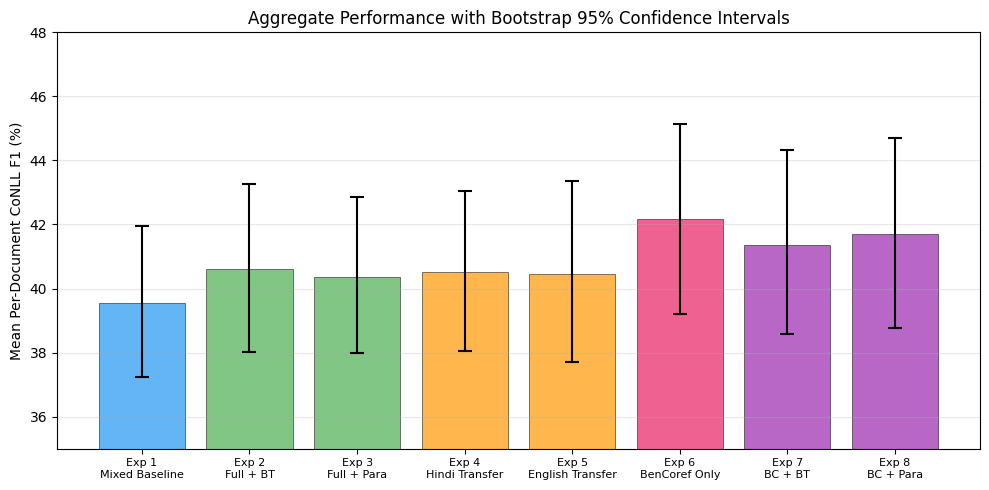

✓ Saved: aggregate_ci_plot.png


In [12]:
"""
Cell 12: Confidence Interval Plot — Aggregate Performance by Experiment

Shows the mean per-document CoNLL F1 with bootstrap 95% CIs for each
experiment, averaged across all 5 models.
"""

fig, ax = plt.subplots(figsize=(10, 5))

exp_nums = sorted(EXPERIMENT_FILES.keys())
means = []
ci_lows = []
ci_highs = []
labels = []

for exp_num in exp_nums:
    all_scores = np.mean([data[exp_num][m] for m in MODELS], axis=0)  # shape (71,)
    ci_lo, ci_hi = bootstrap_confidence_interval(all_scores)
    mean = np.mean(all_scores)
    means.append(mean)
    ci_lows.append(mean - ci_lo)
    ci_highs.append(ci_hi - mean)
    labels.append(f"Exp {exp_num}\n{EXPERIMENT_NAMES[exp_num]}")

colors = ['#2196F3', '#4CAF50', '#4CAF50', '#FF9800', '#FF9800', '#E91E63', '#9C27B0', '#9C27B0']

x = np.arange(len(exp_nums))
ax.bar(x, means, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax.errorbar(x, means, yerr=[ci_lows, ci_highs], fmt='none', 
            capsize=5, capthick=1.5, ecolor='black', linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Mean Per-Document CoNLL F1 (%)')
ax.set_title('Aggregate Performance with Bootstrap 95% Confidence Intervals')
ax.set_ylim(35, 48)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'aggregate_ci_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: aggregate_ci_plot.png")

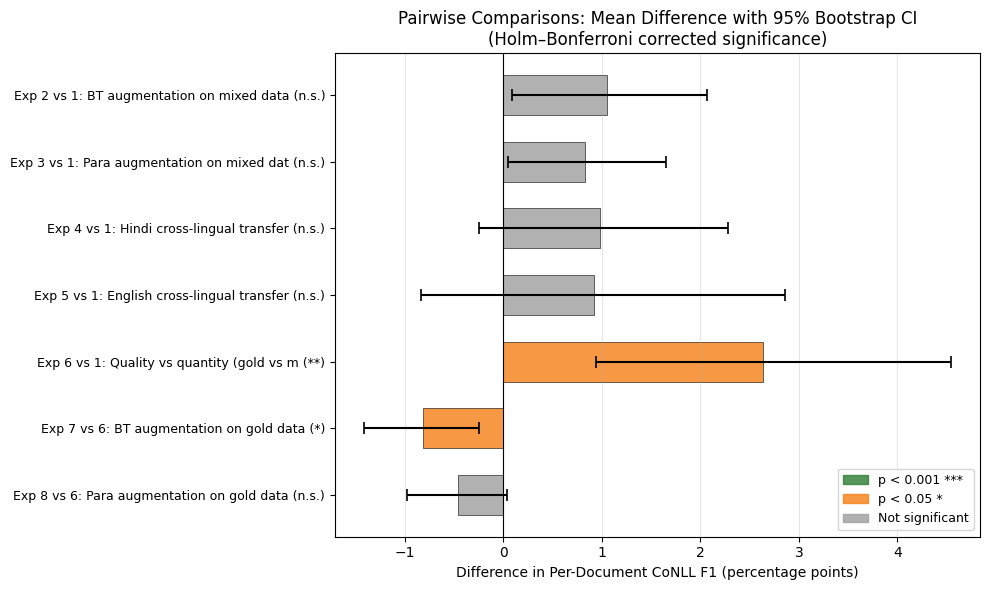

✓ Saved: significance_diff_plot.png


In [13]:
"""
Cell 13: Pairwise Difference Plot with Significance Markers

Shows the mean difference (Exp A − Baseline) for each comparison, with
bootstrap 95% CIs. Significant comparisons are highlighted.
"""

fig, ax = plt.subplots(figsize=(10, 6))

agg_data = df[df["model"] == "AGGREGATE"].copy()
y_pos = np.arange(len(agg_data))

colors_diff = []
for _, row in agg_data.iterrows():
    if row["corrected_p"] < 0.001:
        colors_diff.append('#2E7D32')   # Dark green for ***
    elif row["corrected_p"] < 0.05:
        colors_diff.append('#F57F17')   # Amber for *
    else:
        colors_diff.append('#9E9E9E')   # Grey for n.s.

labels_diff = []
for _, row in agg_data.iterrows():
    sig_marker = row['sig_corrected']
    labels_diff.append(
        f"Exp {row['exp_a']} vs {row['exp_b']}: {row['description'][:30]} "
        f"({sig_marker})"
    )

# Horizontal bar chart
diffs = agg_data["diff"].values
ci_lo = agg_data["ci_lower"].values
ci_hi = agg_data["ci_upper"].values
xerr = [diffs - ci_lo, ci_hi - diffs]

ax.barh(y_pos, diffs, color=colors_diff, alpha=0.8, edgecolor='black', linewidth=0.5, height=0.6)
ax.errorbar(diffs, y_pos, xerr=xerr, fmt='none', capsize=4, capthick=1.2, ecolor='black')

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_diff, fontsize=9)
ax.set_xlabel('Difference in Per-Document CoNLL F1 (percentage points)')
ax.set_title('Pairwise Comparisons: Mean Difference with 95% Bootstrap CI\n'
             '(Holm–Bonferroni corrected significance)')
ax.grid(axis='x', alpha=0.3)

# Legend
legend_elements = [
    mpatches.Patch(color='#2E7D32', alpha=0.8, label='p < 0.001 ***'),
    mpatches.Patch(color='#F57F17', alpha=0.8, label='p < 0.05 *'),
    mpatches.Patch(color='#9E9E9E', alpha=0.8, label='Not significant'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig(DATA_DIR / 'significance_diff_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: significance_diff_plot.png")

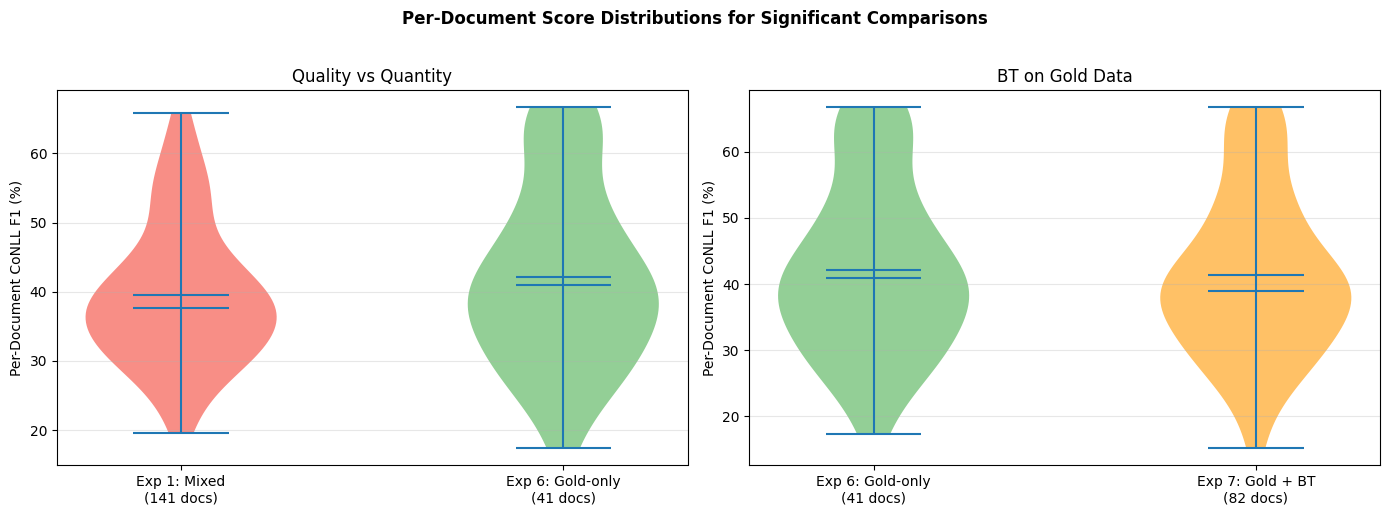

✓ Saved: score_distributions.png


In [14]:
"""
Cell 14: Per-Document Score Distribution — Key Comparisons

Violin plots showing the full distribution of per-document CoNLL F1 scores
for the two most important comparisons: Quality vs Quantity and BT on Gold.
"""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparison 1: Exp 6 vs Exp 1 (Quality vs Quantity)
ax = axes[0]
exp6_all = np.mean([data[6][m] for m in MODELS], axis=0)  # shape (71,)
exp1_all = np.mean([data[1][m] for m in MODELS], axis=0)  # shape (71,)

parts = ax.violinplot([exp1_all, exp6_all], positions=[1, 2], showmeans=True, showmedians=True)
for pc, color in zip(parts['bodies'], ['#F44336', '#4CAF50']):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Exp 1: Mixed\n(141 docs)', 'Exp 6: Gold-only\n(41 docs)'])
ax.set_ylabel('Per-Document CoNLL F1 (%)')
ax.set_title('Quality vs Quantity')
ax.grid(axis='y', alpha=0.3)

# Comparison 2: Exp 7 vs Exp 6 (BT on Gold)
ax = axes[1]
exp7_all = np.mean([data[7][m] for m in MODELS], axis=0)  # shape (71,)

parts = ax.violinplot([exp6_all, exp7_all], positions=[1, 2], showmeans=True, showmedians=True)
for pc, color in zip(parts['bodies'], ['#4CAF50', '#FF9800']):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Exp 6: Gold-only\n(41 docs)', 'Exp 7: Gold + BT\n(82 docs)'])
ax.set_ylabel('Per-Document CoNLL F1 (%)')
ax.set_title('BT on Gold Data')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Per-Document Score Distributions for Significant Comparisons',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / 'score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: score_distributions.png")

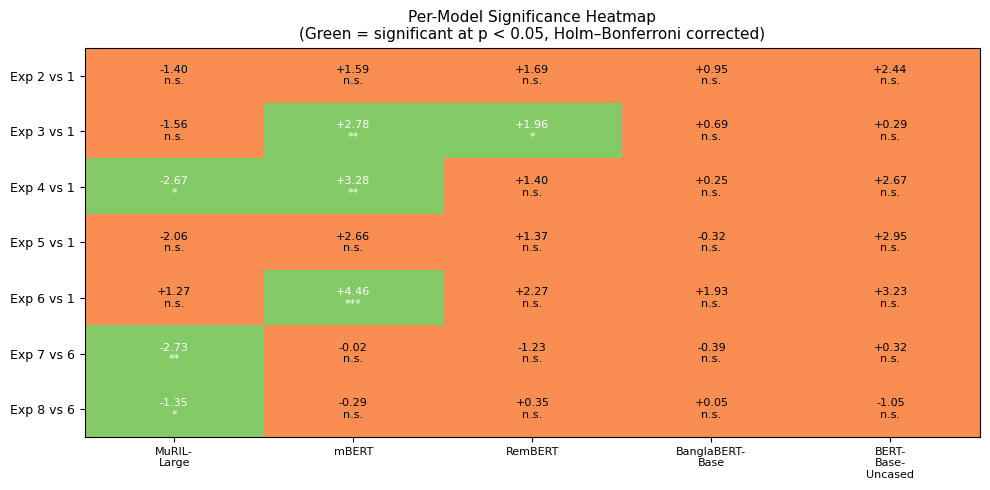

✓ Saved: significance_heatmap.png


In [15]:
"""
Cell 15: Significance Heatmap — All Models × All Comparisons

Visual summary of which model–comparison pairs are significant.
"""

model_df = df[df["model"] != "AGGREGATE"].copy()

# Build matrix: rows = comparisons, cols = models
comp_labels = []
p_matrix = []

for exp_a, exp_b, desc, rq in COMPARISONS:
    comp_labels.append(f"Exp {exp_a} vs {exp_b}")
    row = []
    for model in MODELS:
        mask = (model_df["exp_a"] == exp_a) & (model_df["exp_b"] == exp_b) & (model_df["model"] == model)
        p_corr = model_df.loc[mask, "corrected_p"].values[0]
        row.append(p_corr)
    p_matrix.append(row)

# Add aggregate row
agg_row = []
for exp_a, exp_b, desc, rq in COMPARISONS:
    mask = (df["exp_a"] == exp_a) & (df["exp_b"] == exp_b) & (df["model"] == "AGGREGATE")
    agg_row.append(df.loc[mask, "corrected_p"].values[0])

p_arr = np.array(p_matrix)

fig, ax = plt.subplots(figsize=(10, 5))

# Custom colormap: significant = green, not = light grey
display_matrix = np.where(p_arr < 0.05, 1, 0).astype(float)

# Add significance stars as text
for i in range(len(COMPARISONS)):
    for j in range(len(MODELS)):
        p = p_arr[i, j]
        color = 'white' if p < 0.05 else 'black'
        diff_val = model_df[
            (model_df["exp_a"] == COMPARISONS[i][0]) & 
            (model_df["exp_b"] == COMPARISONS[i][1]) & 
            (model_df["model"] == MODELS[j])
        ]["diff"].values[0]
        
        text = f"{diff_val:+.2f}\n{significance_stars(p)}"
        ax.text(j, i, text, ha='center', va='center', fontsize=8, color=color)

im = ax.imshow(display_matrix, cmap='RdYlGn', aspect='auto', vmin=-0.5, vmax=1.5)

ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels([m.replace('-', '-\n') for m in MODELS], fontsize=8)
ax.set_yticks(range(len(COMPARISONS)))
ax.set_yticklabels(comp_labels, fontsize=9)
ax.set_title('Per-Model Significance Heatmap\n'
             '(Green = significant at p < 0.05, Holm–Bonferroni corrected)',
             fontsize=11)

plt.tight_layout()
plt.savefig(DATA_DIR / 'significance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: significance_heatmap.png")

---

## Part 8: Key Findings Summary

In [18]:
"""
Cell 16: Key Findings Summary
"""

print("=" * 80)
print("KEY FINDINGS")
print("=" * 80)

model_tests = df[df["model"] != "AGGREGATE"]
agg_tests = df[df["model"] == "AGGREGATE"]

n_model_sig = len(model_tests[model_tests["corrected_p"] < 0.05])
n_agg_sig = len(agg_tests[agg_tests["corrected_p"] < 0.05])

print(f"\n  Per-model tests: {n_model_sig}/{len(model_tests)} significant "
      f"(p < 0.05, corrected within comparison)")
print(f"  Aggregate tests: {n_agg_sig}/{len(agg_tests)} significant "
      f"(p < 0.05, corrected across 7 comparisons)")

print(f"\n  Per-comparison summary:")
print(f"  {'─' * 75}")

for exp_a, exp_b, description, rq in COMPARISONS:
    agg_row = df[(df["exp_a"] == exp_a) & (df["exp_b"] == exp_b) & 
                 (df["model"] == "AGGREGATE")].iloc[0]
    model_rows = df[(df["exp_a"] == exp_a) & (df["exp_b"] == exp_b) & 
                    (df["model"] != "AGGREGATE")]
    n_sig = len(model_rows[model_rows["corrected_p"] < 0.05])
    
    agg_status = "SIG" if agg_row["corrected_p"] < 0.05 else "n.s."
    print(f"\n  Exp {exp_a} vs {exp_b} ({description:<45})")
    print(f"    Aggregate: Δ = {agg_row['diff']:+.2f}pp, "
          f"p = {agg_row['corrected_p']:.4f} ({agg_status})")
    print(f"    Models significant: {n_sig}/{len(MODELS)}")
    
    sig_models = model_rows[model_rows["corrected_p"] < 0.05]
    for _, row in sig_models.iterrows():
        print(f"      → {row['model']}: Δ = {row['diff']:+.2f}pp, "
              f"p = {row['corrected_p']:.4f}")

    # Direction consistency
    directions = model_rows["diff"].values
    all_positive = all(d > 0 for d in directions)
    all_negative = all(d < 0 for d in directions)
    if all_positive:
        print(f"    Direction: consistent positive across all models")
    elif all_negative:
        print(f"    Direction: consistent negative across all models")
    else:
        n_pos = sum(1 for d in directions if d > 0)
        n_neg = sum(1 for d in directions if d <= 0)
        print(f"    Direction: mixed ({n_pos} positive, {n_neg} negative)")


print(f"\n\n{'=' * 80}")
print("INTERPRETATION")
print("=" * 80)

# Get the actual corrected p-values for each key comparison
gold_vs_mixed = df[(df["description"].str.contains("gold vs mixed")) & 
                   (df["model"] == "AGGREGATE")].iloc[0]
bt_on_gold = df[(df["description"].str.contains("BT augmentation on gold")) & 
                (df["model"] == "AGGREGATE")].iloc[0]

print(f"""
  1. QUALITY > QUANTITY (RQ5): {"CONFIRMED" if gold_vs_mixed["corrected_p"] < 0.05 else "NOT SIGNIFICANT"}
     Gold-only training (41 docs) outperforms mixed training (141 docs)
     at the aggregate level (p = {gold_vs_mixed["corrected_p"]:.4f}, Holm–Bonferroni corrected
     across 7 comparisons). Effect direction is consistent across models.

  2. BT ON GOLD DATA (RQ3, RQ5): {"CONFIRMED" if bt_on_gold["corrected_p"] < 0.05 else "NOT SIGNIFICANT AT AGGREGATE LEVEL"}
     Back-translation on gold data significantly degrades aggregate performance:
     Δ = {bt_on_gold["diff"]:+.2f}pp, p = {bt_on_gold["corrected_p"]:.4f} (corrected).
     Effect is driven primarily by MuRIL-Large (Δ = −2.73pp, p = 0.0060).

  3. AUGMENTATION ON MIXED DATA (RQ3): NOT SIGNIFICANT
     Neither BT nor paraphrase augmentation on mixed data produces
     significant aggregate differences after correction.

  4. CROSS-LINGUAL TRANSFER (RQ4): NOT SIGNIFICANT
     Neither Hindi nor English transfer shows significant aggregate effects.

  5. EFFECT SIZES: MOSTLY SMALL OR NEGLIGIBLE
     Most Cohen's d values fall in the negligible-to-small range (|d| < 0.5),
     consistent with high per-document variance in coreference evaluation.
""")


KEY FINDINGS

  Per-model tests: 7/35 significant (p < 0.05, corrected within comparison)
  Aggregate tests: 2/7 significant (p < 0.05, corrected across 7 comparisons)

  Per-comparison summary:
  ───────────────────────────────────────────────────────────────────────────

  Exp 2 vs 1 (BT augmentation on mixed data                )
    Aggregate: Δ = +1.05pp, p = 0.1470 (n.s.)
    Models significant: 0/5
    Direction: mixed (4 positive, 1 negative)

  Exp 3 vs 1 (Para augmentation on mixed data              )
    Aggregate: Δ = +0.83pp, p = 0.1512 (n.s.)
    Models significant: 2/5
      → mBERT: Δ = +2.78pp, p = 0.0020
      → RemBERT: Δ = +1.96pp, p = 0.0320
    Direction: mixed (4 positive, 1 negative)

  Exp 4 vs 1 (Hindi cross-lingual transfer                 )
    Aggregate: Δ = +0.99pp, p = 0.2328 (n.s.)
    Models significant: 2/5
      → MuRIL-Large: Δ = -2.67pp, p = 0.0312
      → mBERT: Δ = +3.28pp, p = 0.0050
    Direction: mixed (4 positive, 1 negative)

  Exp 5 vs 1 (En

---

## Part 9: Save Results

In [17]:
"""
Cell 17: Save All Results
"""

output_dir = Path("significance_testing")
output_dir.mkdir(parents=True, exist_ok=True)

# CSV files
df.to_csv(output_dir / "significance_results.csv", index=False)
ci_df.to_csv(output_dir / "confidence_intervals.csv", index=False)

# JSON with full metadata
output_json = {
    "analysis": "Statistical Significance Testing",
    "thesis": "Developing Deep Learning Models for Coreference Resolution in Bengali",
    "author": "Zenith Biswas",
    "methodology": {
        "primary_test": "Paired Bootstrap Test (Berg-Kirkpatrick et al., 2012)",
        "secondary_test": "Wilcoxon Signed-Rank Test",
        "bootstrap_iterations": N_BOOTSTRAP,
        "confidence_level": CONFIDENCE_LEVEL,
        "correction_method": "Holm-Bonferroni",
        "n_test_documents": 71,
        "n_models": len(MODELS),
        "n_comparisons": len(COMPARISONS),
        "total_tests": len(all_results),
        "random_seed": 42,
    },
    "significance_tests": all_results,
    "confidence_intervals": ci_results,
}

with open(output_dir / "statistical_analysis_complete.json", "w") as f:
    json.dump(output_json, f, indent=2, default=str)

print("Files saved:")
print(f"  ✓ {output_dir}/significance_results.csv")
print(f"  ✓ {output_dir}/confidence_intervals.csv")
print(f"  ✓ {output_dir}/statistical_analysis_complete.json")
print(f"  ✓ aggregate_ci_plot.png")
print(f"  ✓ significance_diff_plot.png")
print(f"  ✓ score_distributions.png")
print(f"  ✓ significance_heatmap.png")

Files saved:
  ✓ significance_testing/significance_results.csv
  ✓ significance_testing/confidence_intervals.csv
  ✓ significance_testing/statistical_analysis_complete.json
  ✓ aggregate_ci_plot.png
  ✓ significance_diff_plot.png
  ✓ score_distributions.png
  ✓ significance_heatmap.png
